In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random, os, json, warnings
from collections import deque

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils import resample

warnings.filterwarnings('ignore')




In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


TRAIN_CSV  = '../../data/processed/2017/2017_train_scaled.csv'
TEST_CSV   = '../../data/processed/2017/2017_test_scaled.csv'
OUTPUT_DIR = '../../models/phase1/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.21.0
GPU        : []


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train brut : {train_df.shape}  |  Test brut : {test_df.shape}')
print(f'\nDistribution labels (train) :')
print(train_df['Label'].value_counts().to_string())

Train brut : (2262300, 50)  |  Test brut : (565576, 50)

Distribution labels (train) :
Label
0    1817055
1     445245


In [11]:
FEATURES = [c for c in train_df.columns if c not in ('Label', 'y')]
print(f'Nombre de features : {len(FEATURES)}')

Nombre de features : 49


In [12]:
print(f'BENIGN  (0) : {(train_df["Label"]==0).sum():,}')
print(f'ATTACK  (1) : {(train_df["Label"]==1).sum():,}')

df_benign  = train_df[train_df['Label'] == 0]
df_attacks = train_df[train_df['Label'] == 1]
n_min = len(df_attacks)

df_benign_under = resample(df_benign, replace=False,
                            n_samples=n_min, random_state=SEED)
train_balanced  = pd.concat([df_benign_under, df_attacks]) \
                    .sample(frac=1, random_state=SEED)     \
                    .reset_index(drop=True)

print(f'\nTrain après 1:1 undersampling : {len(train_balanced):,}')
print(f'  BENIGN  : {(train_balanced["Label"]==0).sum():,}')
print(f'  ATTACK  : {(train_balanced["Label"]==1).sum():,}')

X_train = train_balanced[FEATURES].values.astype(np.float32)
y_train = train_balanced['Label'].values.astype(np.int32)
X_test  = test_df[FEATURES].values.astype(np.float32)
y_test  = test_df['Label'].values.astype(np.int32)

print(f'\nX_train : {X_train.shape}  |  X_test : {X_test.shape}')

BENIGN  (0) : 1,817,055
ATTACK  (1) : 445,245

Train après 1:1 undersampling : 890,490
  BENIGN  : 445,245
  ATTACK  : 445,245

X_train : (890490, 49)  |  X_test : (565576, 49)


In [13]:
def build_dueling_dqn(input_dim: int, n_actions: int = 2,
                      hidden: list = [256, 128],
                      stream_units: int = 64,
                      lr: float = 1e-3) -> keras.Model:
    """.
    Q(s,a) = V(s) + [ A(s,a) − mean_a' A(s,a') ]
    """
    inp = keras.Input(shape=(input_dim,), name='state')

    
    x = inp
    for u in hidden:
        x = layers.Dense(u, activation='relu',
                         kernel_initializer='he_uniform')(x)

    
    v = layers.Dense(stream_units, activation='relu',
                     kernel_initializer='he_uniform', name='v_dense')(x)
    v = layers.Dense(1, name='V')(v)                          

    
    a = layers.Dense(stream_units, activation='relu',
                     kernel_initializer='he_uniform', name='a_dense')(x)
    a = layers.Dense(n_actions, name='A')(a)                 

    
    q = layers.Lambda(
        lambda va: va[0] + (va[1] - tf.reduce_mean(va[1], axis=1, keepdims=True)),
        name='Q'
    )([v, a])

    model = keras.Model(inputs=inp, outputs=q, name='DuelingDQN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.Huber()   # δ-insensitive aux outliers
    )
    return model


_m = build_dueling_dqn(len(FEATURES))
_m.summary()
print(f'\nParamètres totaux : {_m.count_params():,}')
del _m

Model: "DuelingDQN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state (InputLayer)  │ (None, 49)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     12,800 │ state[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v_dense (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ a_dense (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V (Dense)           │ (None, 1)         │         65 │ v_dense[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ A (Dense)           │ (None, 2)         │        130 │ a_dense[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Q (Lambda)          │ (None, 2)         │          0 │ V[0][0], A[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,403 (243.76 KB)

 Trainable params: 62,403 (243.76 KB)

 Non-trainable params: 0 (0.00 B)


Paramètres totaux : 62,403


In [17]:
class IDSEnv:
    """
    Environnement MDP pour la détection d'intrusion.
    À chaque step : l'agent reçoit un vecteur de features,
    choisit 0 (bénin) ou 1 (malicieux), reçoit la récompense asymétrique.

    Récompense Phase I (ratio 5:1) :
      +1.0  →  bonne classification
      −1.0  →  fausse alarme   (FP : bénin classé malicieux)
      −5.0  →  attaque ratée   (FN : malicieux classé bénin)
    """
    def __init__(self, X, y, r_ok=+1.0, r_fp=-1.0, r_fn=-5.0, seed=SEED):
        self.X = X; self.y = y; self.N = len(X)
        self.r_ok = r_ok; self.r_fp = r_fp; self.r_fn = r_fn
        self._rng = np.random.default_rng(seed)
        self._order = self._rng.permutation(self.N)
        self._idx = 0

    def reset(self):
        self._order = self._rng.permutation(self.N)
        self._idx = 0
        return self.X[self._order[0]]

    def step(self, action: int):
        true_label = self.y[self._order[self._idx]]
        if   action == true_label          : reward = self.r_ok
        elif action == 1 and true_label==0 : reward = self.r_fp  # FP
        else                               : reward = self.r_fn  # FN

        self._idx += 1
        done = self._idx >= self.N
        next_s = self.X[self._order[self._idx]] if not done \
                 else np.zeros(self.X.shape[1], dtype=np.float32)
        return next_s, reward, done, true_label


class ReplayBuffer:
    def __init__(self, maxlen=10_000):
        self._buf = deque(maxlen=maxlen)

    def push(self, s, a, r, ns, d):
        self._buf.append((s, a, r, ns, d))

    def sample(self, n):
        batch = random.sample(self._buf, n)
        s, a, r, ns, d = zip(*batch)
        return (np.array(s,  np.float32), np.array(a,  np.int32),
                np.array(r,  np.float32), np.array(ns, np.float32),
                np.array(d,  np.float32))

    def __len__(self): return len(self._buf)



In [18]:
class DuelingDQNAgent:

    
    GAMMA          = 0.99
    LR             = 1e-3
    EPS_START      = 1.0
    EPS_MIN        = 0.01
    EPS_DECAY      = 0.995
    BATCH_SIZE     = 64
    REPLAY_SIZE    = 10_000
    TARGET_UPD_EP  = 1       
    N_EPISODES     = 60
    STEPS_PER_EP   = 500

    def __init__(self, input_dim: int, seed: int = SEED):
        tf.random.set_seed(seed * 100 + SEED)
        np.random.seed(seed * 100 + SEED)
        random.seed(seed * 100 + SEED)

        self.online = build_dueling_dqn(input_dim, lr=self.LR)
        self.target = build_dueling_dqn(input_dim, lr=self.LR)
        self.target.set_weights(self.online.get_weights())  

        self.replay   = ReplayBuffer(self.REPLAY_SIZE)
        self.epsilon  = self.EPS_START
        self._losses  = []

    
    def act(self, state: np.ndarray, greedy: bool = False) -> int:
        if not greedy and random.random() < self.epsilon:
            return random.randint(0, 1)
        q = self.online(state[np.newaxis], training=False)
        return int(tf.argmax(q[0]).numpy())

    
    def step_learn(self, s, a, r, ns, done) -> float:
        self.replay.push(s, a, r, ns, done)
        if len(self.replay) < self.BATCH_SIZE:
            return 0.0

        states, actions, rewards, next_s, dones = \
            self.replay.sample(self.BATCH_SIZE)

        q_next    = self.target(next_s, training=False).numpy()
        q_targets = rewards + self.GAMMA * np.max(q_next, axis=1) * (1 - dones)

        q_pred = self.online(states, training=False).numpy()
        q_pred[np.arange(self.BATCH_SIZE), actions] = q_targets

        loss = self.online.train_on_batch(states, q_pred)
        self._losses.append(float(loss))
        return float(loss)

    def decay_eps(self):
        self.epsilon = max(self.EPS_MIN, self.epsilon * self.EPS_DECAY)

    def hard_update(self):
        self.target.set_weights(self.online.get_weights())

    def predict_batch(self, X: np.ndarray) -> np.ndarray:
        q = self.online.predict(X, batch_size=4096, verbose=0)
        return np.argmax(q, axis=1)

    def save(self, path: str):
        self.online.save(path)



In [19]:
def run_one(run_id: int, X_tr, y_tr, X_te, y_te,
            verbose: bool = True) -> dict:
    """
    Entraîne un agent Dueling DQN pour un run et retourne
    les métriques test + courbes d'entraînement.
    """
    agent = DuelingDQNAgent(input_dim=X_tr.shape[1], seed=run_id)
    env   = IDSEnv(X_tr, y_tr, seed=run_id)

    ep_rewards, ep_recall, ep_f1 = [], [], []

    for ep in range(agent.N_EPISODES):
        state       = env.reset()
        total_r     = 0.0
        ep_pred     = []
        ep_true_lbl = []

        for _ in range(agent.STEPS_PER_EP):
            action              = agent.act(state)
            ns, reward, done, lbl = env.step(action)

            agent.step_learn(state, action, reward, ns, float(done))
            ep_pred.append(action)
            ep_true_lbl.append(lbl)
            total_r += reward
            state = ns
            if done:
                break

        agent.decay_eps()

       
        if (ep + 1) % agent.TARGET_UPD_EP == 0:
            agent.hard_update()

        r  = recall_score(ep_true_lbl, ep_pred, zero_division=0)
        f1 = f1_score(ep_true_lbl, ep_pred, zero_division=0)
        ep_rewards.append(total_r)
        ep_recall.append(r)
        ep_f1.append(f1)

        if verbose and (ep + 1) % 10 == 0:
            print(f'  Run {run_id+1} | Ep {ep+1:3d}/{agent.N_EPISODES} | '
                  f'Reward {total_r:8.1f} | Recall {r:.4f} | '
                  f'F1 {f1:.4f} | ε {agent.epsilon:.3f}')

  
    preds = agent.predict_batch(X_te)
    cm    = confusion_matrix(y_te, preds)
    metrics = dict(
        accuracy  = accuracy_score(y_te, preds),
        recall    = recall_score(y_te, preds, zero_division=0),
        precision = precision_score(y_te, preds, zero_division=0),
        f1        = f1_score(y_te, preds, zero_division=0),
        cm        = cm.tolist()
    )
    return dict(agent=agent, metrics=metrics,
                ep_rewards=ep_rewards, ep_recall=ep_recall,
                ep_f1=ep_f1, losses=agent._losses)



In [20]:
N_RUNS = 5
results = []

print(f'=== Phase I — {N_RUNS} runs indépendants ===')
print(f'Features : {len(FEATURES)} | '
      f'Train équilibré : {len(X_train):,} | '
      f'Test (réel) : {len(X_test):,}\n')

for run_id in range(N_RUNS):
    print(f'── Run {run_id+1}/{N_RUNS} ──────────────────────────────')
    res = run_one(run_id, X_train, y_train, X_test, y_test)
    results.append(res)
    m = res['metrics']
    print(f'  ✓ Test → Acc {m["accuracy"]:.4f} | '
          f'Recall {m["recall"]:.4f} | '
          f'Prec {m["precision"]:.4f} | '
          f'F1 {m["f1"]:.4f}\n')

print('Entraînement terminé.')

=== Phase I — 5 runs indépendants ===
Features : 49 | Train équilibré : 890,490 | Test (réel) : 565,576

── Run 1/5 ──────────────────────────────
  Run 1 | Ep  10/60 | Reward   -414.0 | Recall 0.5246 | F1 0.5322 | ε 0.951
  Run 1 | Ep  20/60 | Reward   -390.0 | Recall 0.5447 | F1 0.5481 | ε 0.905
  Run 1 | Ep  30/60 | Reward   -520.0 | Recall 0.4797 | F1 0.4816 | ε 0.860
  Run 1 | Ep  40/60 | Reward   -294.0 | Recall 0.6100 | F1 0.6184 | ε 0.818
  Run 1 | Ep  50/60 | Reward   -366.0 | Recall 0.5802 | F1 0.5880 | ε 0.778
  Run 1 | Ep  60/60 | Reward   -258.0 | Recall 0.6462 | F1 0.6328 | ε 0.740
  ✓ Test → Acc 0.9669 | Recall 0.9927 | Prec 0.8606 | F1 0.9219

── Run 2/5 ──────────────────────────────
  Run 2 | Ep  10/60 | Reward   -454.0 | Recall 0.4825 | F1 0.4772 | ε 0.951
  Run 2 | Ep  20/60 | Reward   -490.0 | Recall 0.5042 | F1 0.4850 | ε 0.905
  Run 2 | Ep  30/60 | Reward   -390.0 | Recall 0.5649 | F1 0.5770 | ε 0.860
  Run 2 | Ep  40/60 | Reward   -436.0 | Recall 0.5276 | F1 0.5

In [28]:
keys = ['accuracy', 'recall', 'precision', 'f1']
vals = {k: [r['metrics'][k] for r in results] for k in keys}

summary = pd.DataFrame({
    'µ (mean)': {k: np.mean(v) for k, v in vals.items()},
    'σ (std)' : {k: np.std(v)  for k, v in vals.items()},
})
summary['µ ± σ'] = summary.apply(
    lambda r: f"{r['µ (mean)']:.4f} ± {r['σ (std)']:.4f}", axis=1
)

print('=== Résultats Phase I  — 5 runs ===')
display(summary[['µ ± σ', 'µ (mean)', 'σ (std)']].rename(
    columns={'µ (mean)': 'Mean', 'σ (std)': 'Std'}))



=== Résultats Phase I  — 5 runs ===


,µ ± σ,Mean,Std
accuracy,0.9632 ± 0.0022,0.963204,0.002248
recall,0.9929 ± 0.0021,0.992897,0.002106
precision,0.8467 ± 0.0085,0.846726,0.008538
f1,0.9140 ± 0.0048,0.913978,0.004793


In [24]:
best_run = max(range(N_RUNS), key=lambda i: results[i]['metrics']['f1'])
print(f'Meilleur run : Run {best_run+1} '
      f'(F1={results[best_run]["metrics"]["f1"]:.4f})\n')

best_preds = results[best_run]['agent'].predict_batch(X_test)
print(classification_report(
    y_test, best_preds,
    target_names=['BENIGN (0)', 'ATTACK (1)'],
    digits=4
))

Meilleur run : Run 1 (F1=0.9219)

              precision    recall  f1-score   support

  BENIGN (0)     0.9981    0.9606    0.9790    454265
  ATTACK (1)     0.8606    0.9927    0.9219    111311

    accuracy                         0.9669    565576
   macro avg     0.9294    0.9766    0.9505    565576
weighted avg     0.9711    0.9669    0.9678    565576



In [25]:
print('=== Stability Analysis (TN | FP | FN | TP) ===')
print(f'{"Run":<6} {"TN (B→B)":>12} {"FP (B→M)":>12} {"FN (M→B)":>12} {"TP (M→M)":>12}')
print('-' * 56)
for i, res in enumerate(results):
    cm = np.array(res['metrics']['cm'])
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f'{i+1:<6} {tn:>12,} {fp:>12,} {fn:>12,} {tp:>12,}')


cms = np.array([r['metrics']['cm'] for r in results])
m_cm = cms.mean(axis=0)
print('-' * 56)
print(f'{"Moy.":<6} {m_cm[0,0]:>12,.0f} {m_cm[0,1]:>12,.0f} '
      f'{m_cm[1,0]:>12,.0f} {m_cm[1,1]:>12,.0f}')

=== Stability Analysis (TN | FP | FN | TP) ===
Run        TN (B→B)     FP (B→M)     FN (M→B)     TP (M→M)
--------------------------------------------------------
1           436,372       17,893          816      110,495
2           432,421       21,844          780      110,531
3           434,559       19,706          775      110,536
4           433,368       20,897          421      110,890
5           434,503       19,762        1,161      110,150
--------------------------------------------------------
Moy.        434,245       20,020          791      110,520


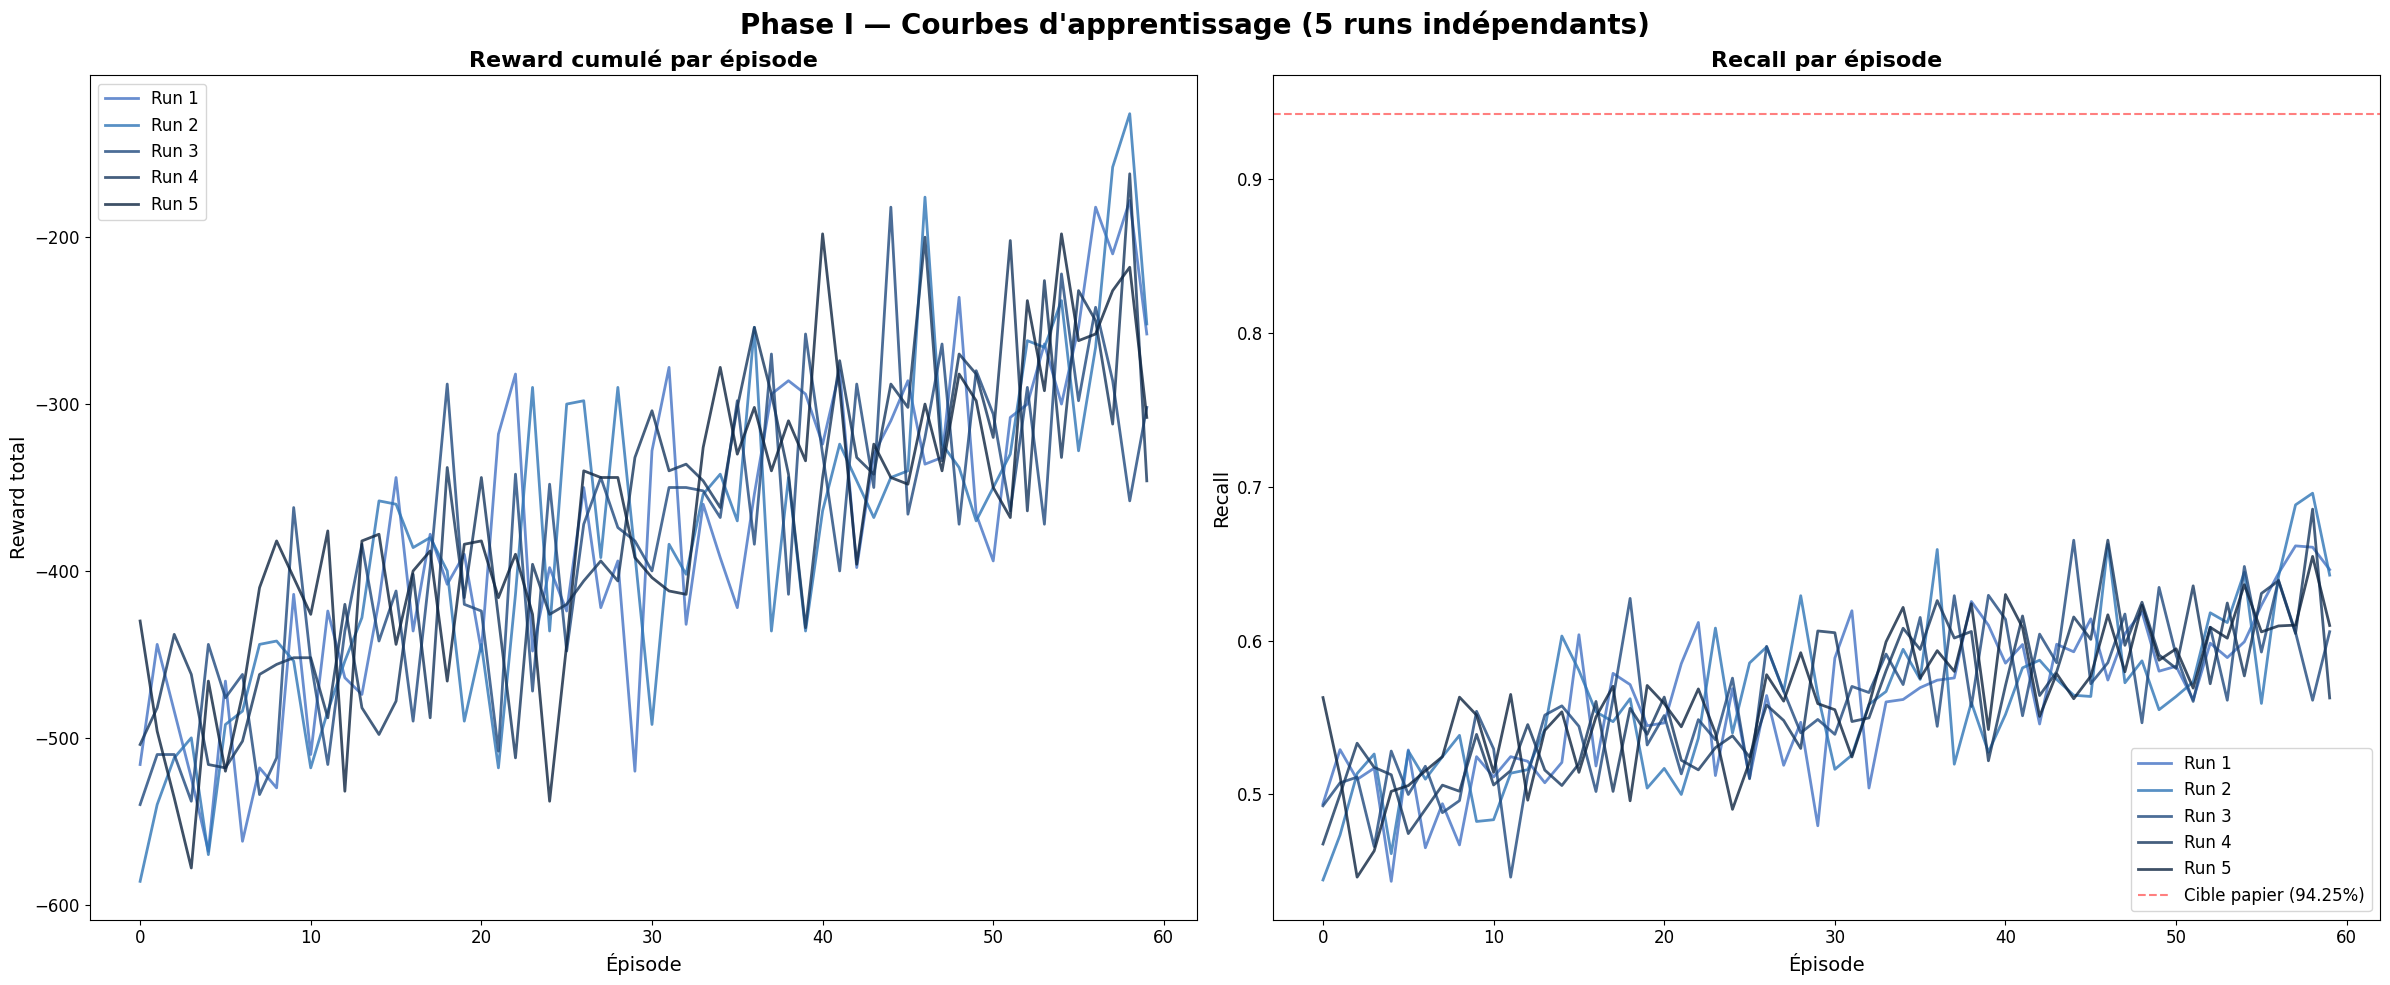

In [ ]:
pal = ['#4472C4','#2E75B6','#1F497D','#17375E','#0D2440']

fig, axes = plt.subplots(1, 2, figsize=(30, 14))
fig.suptitle("Phase I — Courbes d'apprentissage (5 runs indépendants)",
             fontsize=26, fontweight='bold')

for i, res in enumerate(results):
    axes[0].plot(res['ep_rewards'], color=pal[i], alpha=0.8,
                 linewidth=3, label=f'Run {i+1}')
    axes[1].plot(res['ep_recall'],  color=pal[i], alpha=0.8,
                 linewidth=3, label=f'Run {i+1}')

axes[0].set_title('Reward cumulé par épisode', fontweight='bold', fontsize=20)
axes[1].set_title('Recall par épisode', fontweight='bold', fontsize=20)
for ax in axes:
    ax.set_xlabel('Épisode', fontsize=16)
    ax.legend(fontsize=14)
    ax.tick_params(labelsize=14)
axes[0].set_ylabel('Reward total', fontsize=16)
axes[1].set_ylabel('Recall', fontsize=16)
axes[1].axhline(0.9425, color='red', linestyle='--', alpha=0.5, linewidth=2.5,
                label='Cible papier (94.25%)')
axes[1].legend(fontsize=14)

plt.tight_layout()
plt.show()

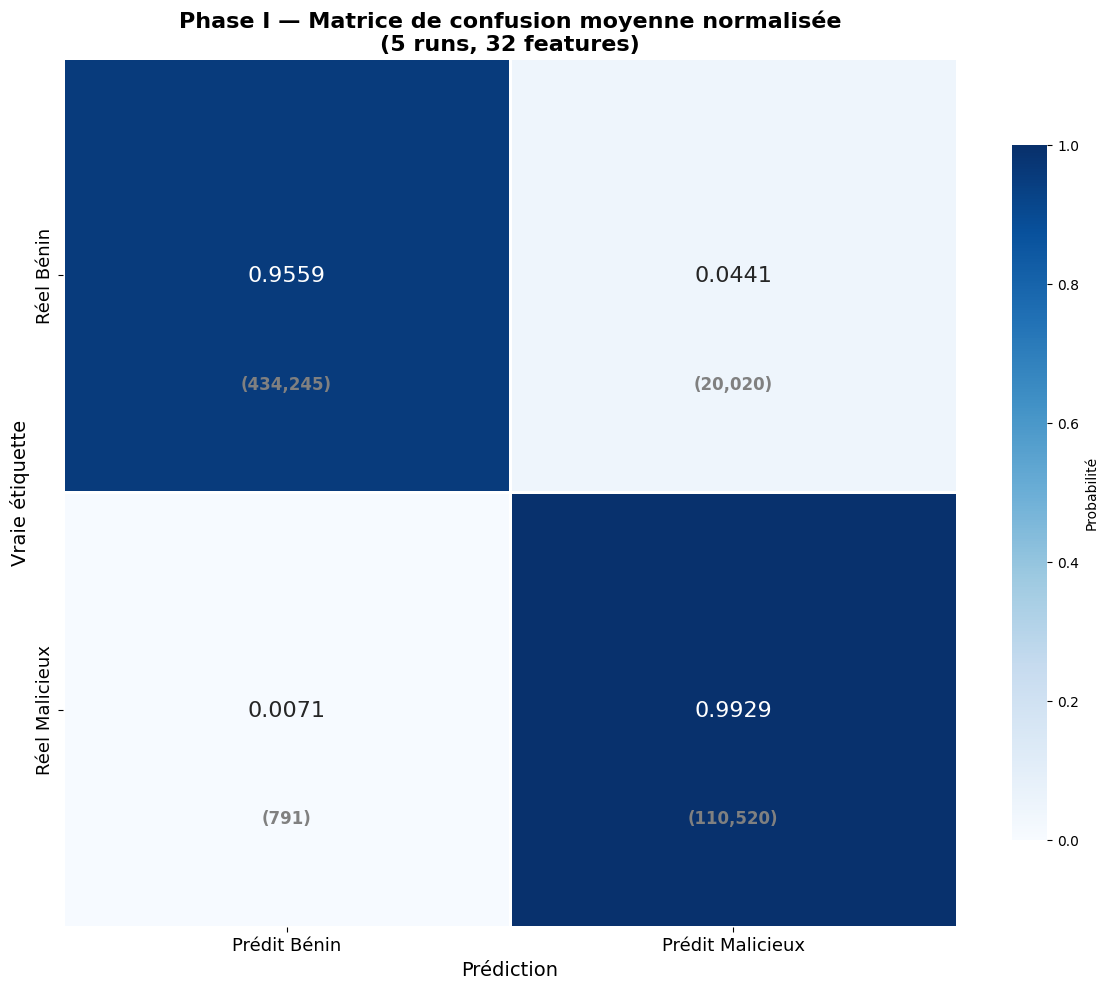

In [ ]:
mean_cm      = cms.mean(axis=0)
mean_cm_norm = mean_cm / mean_cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(mean_cm_norm, annot=True, fmt='.4f', cmap='Blues',
            xticklabels=['Prédit Bénin', 'Prédit Malicieux'],
            yticklabels=['Réel Bénin', 'Réel Malicieux'],
            ax=ax, vmin=0, vmax=1, linewidths=1, annot_kws={'size': 16}, cbar_kws={'label': 'Probabilité', 'shrink': 0.8})

ax.tick_params(labelsize=13)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, f'({mean_cm[i,j]:,.0f})',
                ha='center', va='center', fontsize=12, color='gray', fontweight='bold')

ax.set_title('Phase I — Matrice de confusion moyenne normalisée\n(5 runs, 32 features)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Prédiction', fontsize=14)
ax.set_ylabel('Vraie étiquette', fontsize=14)
plt.tight_layout()
plt.show()


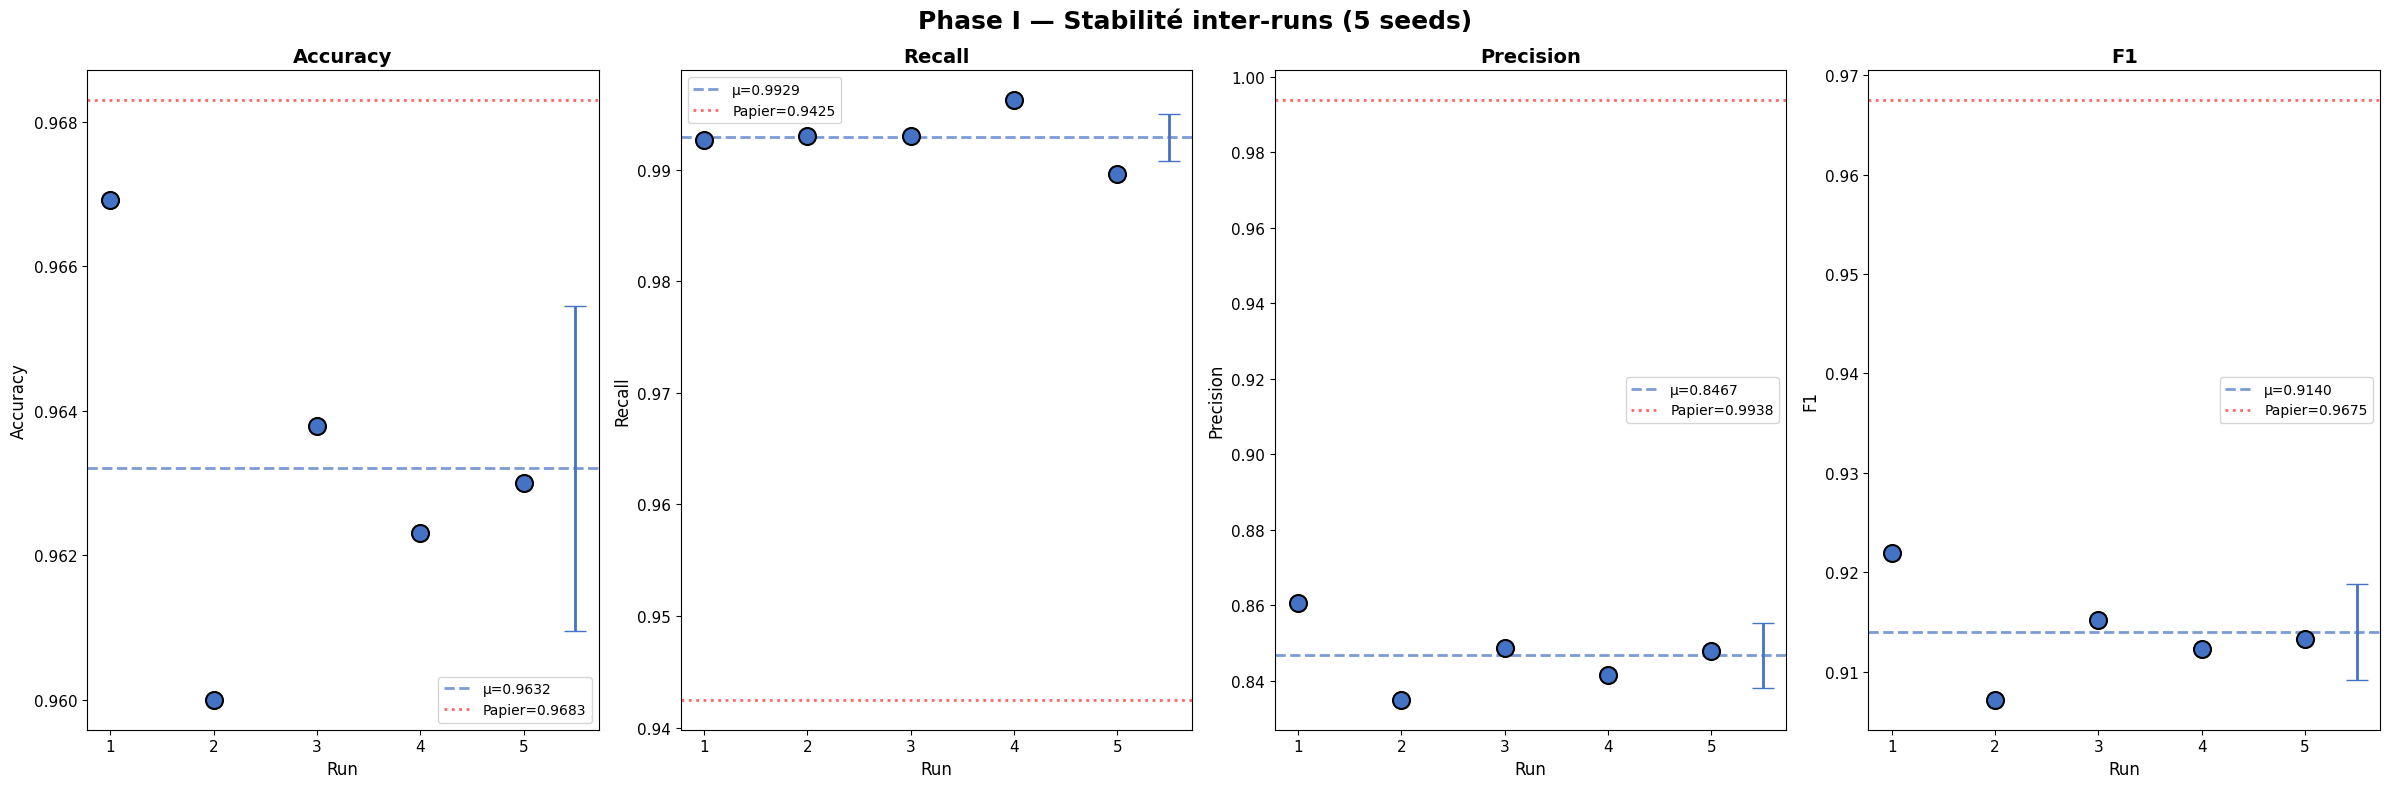

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
fig.suptitle('Phase I — Stabilité inter-runs (5 seeds)',
             fontsize=18, fontweight='bold')

targets_vals = dict(accuracy=0.9683, recall=0.9425,
                    precision=0.9938, f1=0.9675)

for ax, metric in zip(axes, keys):
    v = vals[metric]
    runs = list(range(1, N_RUNS+1))
    ax.scatter(runs, v, color='#4472C4', s=150, zorder=5, edgecolors='black', linewidth=1.5)
    ax.axhline(np.mean(v), color='#4472C4', linestyle='--',
               alpha=0.7, linewidth=2, label=f'µ={np.mean(v):.4f}')
    ax.axhline(targets_vals[metric], color='red', linestyle=':',
               alpha=0.6, linewidth=2, label=f'Papier={targets_vals[metric]:.4f}')
    
    ax.errorbar([N_RUNS + 0.5], [np.mean(v)], yerr=[np.std(v)],
                color='#4472C4', capsize=8, linewidth=3, elinewidth=2)
    ax.set_title(metric.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xticks(runs)
    ax.set_xlabel('Run', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


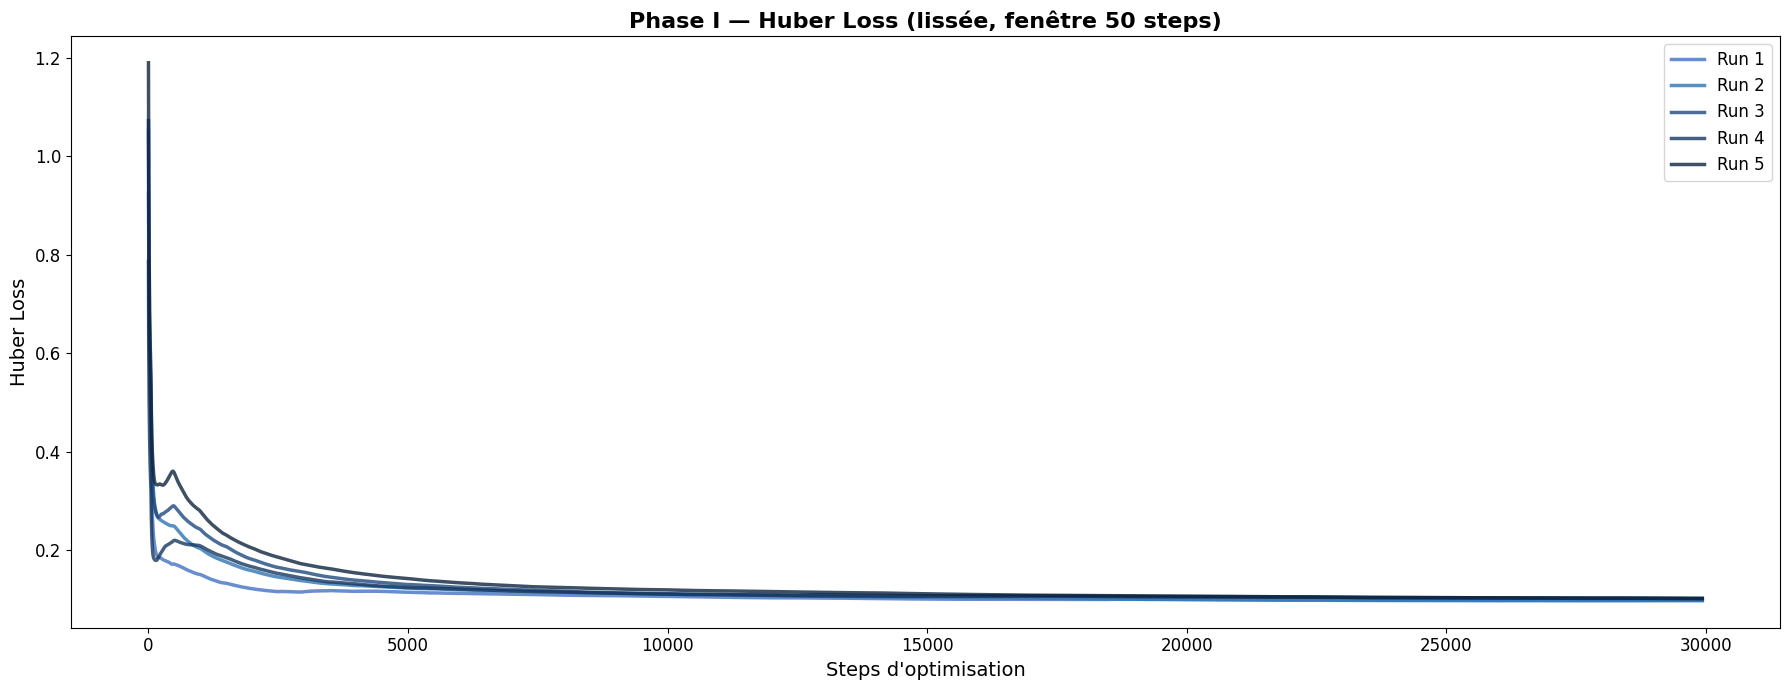

In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))
for i, res in enumerate(results):
    smooth = pd.Series(res['losses']).rolling(50, min_periods=1).mean()
    ax.plot(smooth, color=pal[i], alpha=0.8, linewidth=2.5,
            label=f'Run {i+1}')

ax.set_title('Phase I — Huber Loss (lissée, fenêtre 50 steps)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Steps d\'optimisation', fontsize=14)
ax.set_ylabel('Huber Loss', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()
